<a href="https://colab.research.google.com/github/TeodoraCain/EatWell-Calorie-Counter/blob/master/Classification_model_for_Eatwell.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
!unzip /content/drive/MyDrive/final_datasets.zip

Streaming output truncated to the last 5000 lines.
  inflating: Final datasets/omelette/1626742.jpg  
  inflating: Final datasets/omelette/1629438.jpg  
  inflating: Final datasets/omelette/1631980.jpg  
  inflating: Final datasets/omelette/1632513.jpg  
  inflating: Final datasets/omelette/1632587.jpg  
  inflating: Final datasets/omelette/1636436.jpg  
  inflating: Final datasets/omelette/1637548.jpg  
  inflating: Final datasets/omelette/1640730.jpg  
  inflating: Final datasets/omelette/1640872.jpg  
  inflating: Final datasets/omelette/1644626.jpg  
  inflating: Final datasets/omelette/1652710.jpg  
  inflating: Final datasets/omelette/1658503.jpg  
  inflating: Final datasets/omelette/1658549.jpg  
  inflating: Final datasets/omelette/1664703.jpg  
  inflating: Final datasets/omelette/1668780.jpg  
  inflating: Final datasets/omelette/1668939.jpg  
  inflating: Final datasets/omelette/1675150.jpg  
  inflating: Final datasets/omelette/1681866.jpg  
  inflating: Final datasets/ome

In [ ]:
import os
import shutil
import random
from pathlib import Path

# Sursă inițială
src_dir = '/content/Final datasets'
output_dir = '/content/split_dataset'

# Setări
target_images_per_class = 331
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Curăță vechiul folder (dacă există)
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir)

# Creează directoare noi
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(output_dir, split), exist_ok=True)

# Parcurge fiecare clasă
for class_name in os.listdir(src_dir):
    class_path = os.path.join(src_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    # Obține toate imaginile
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if len(images) < target_images_per_class:
        print(f"⚠️ Clasa '{class_name}' are doar {len(images)} imagini. Ignorată.")
        continue

    selected_images = random.sample(images, target_images_per_class)

    # Split
    train_count = int(train_ratio * target_images_per_class)
    val_count = int(val_ratio * target_images_per_class)

    train_images = selected_images[:train_count]
    val_images = selected_images[train_count:train_count+val_count]
    test_images = selected_images[train_count+val_count:]

    # Copiază imaginile
    for split_name, split_images in zip(['train', 'val', 'test'], [train_images, val_images, test_images]):
        split_class_dir = os.path.join(output_dir, split_name, class_name)
        os.makedirs(split_class_dir, exist_ok=True)
        for img in split_images:
            src_img = os.path.join(class_path, img)
            dst_img = os.path.join(split_class_dir, img)
            shutil.copy2(src_img, dst_img)

    print(f"✅ Clasa '{class_name}' procesată cu 331 imagini (train/val/test)")

print("\n📁 Datele sunt pregătite în: /content/split_dataset")

✅ Clasa 'burger' procesată cu 331 imagini (train/val/test)
✅ Clasa 'sweetcorn' procesată cu 331 imagini (train/val/test)
✅ Clasa 'mushroom' procesată cu 331 imagini (train/val/test)
✅ Clasa 'strawberries' procesată cu 331 imagini (train/val/test)
✅ Clasa 'mango' procesată cu 331 imagini (train/val/test)
✅ Clasa 'pear' procesată cu 331 imagini (train/val/test)
✅ Clasa 'potato' procesată cu 331 imagini (train/val/test)
✅ Clasa 'avocado' procesată cu 331 imagini (train/val/test)
✅ Clasa 'banana' procesată cu 331 imagini (train/val/test)
✅ Clasa 'kiwi' procesată cu 331 imagini (train/val/test)
✅ Clasa 'pizza' procesată cu 331 imagini (train/val/test)
✅ Clasa 'bell_pepper' procesată cu 331 imagini (train/val/test)
✅ Clasa 'garlic' procesată cu 331 imagini (train/val/test)
✅ Clasa 'orange' procesată cu 331 imagini (train/val/test)
✅ Clasa 'grapes' procesată cu 331 imagini (train/val/test)
✅ Clasa 'apple' procesată cu 331 imagini (train/val/test)
✅ Clasa 'pinenapple' procesată cu 331 imagini 

In [ ]:
# Numele claselor
import os
root_path = '/content/split_dataset/train/'
class_names = sorted(os.listdir(root_path))
n_classes = len(class_names)

# Distribuția claselor
class_dis = [len(os.listdir(root_path + name)) for name in class_names]


# Afișare
print(f"Total Number of Classes : {n_classes} \nClass Names : {class_names}")

Total Number of Classes : 33 
Class Names : ['apple', 'avocado', 'baked_potato', 'banana', 'bell_pepper', 'broccoli', 'burger', 'carrot', 'cauliflower', 'cheesecake', 'cherry', 'cucumber', 'eggplant', 'fries', 'garlic', 'grapes', 'ice_cream', 'kiwi', 'lemon', 'mango', 'mushroom', 'omelette', 'onion', 'orange', 'pear', 'pinenapple', 'pizza', 'potato', 'spinach', 'strawberries', 'sweetcorn', 'tomato', 'watermelon']


In [ ]:
# Visualizare
import plotly.express as px
fig = px.pie(names=class_names, values=class_dis, title="Class Distribution", hole=0.1)
fig.update_layout({'title':{'x':0.6}})
fig.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Setări
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = n_classes
EPOCHS = 30

# Augumentarea datelor
train_datagen = ImageDataGenerator(
    rescale=1./255, # normalizează valorile pixelilor
    rotation_range=15,  # rotații aleatorii
    width_shift_range=0.1, # deplasări orizontale
    height_shift_range=0.1, # deplasări verticale
    zoom_range=0.1, # zoom aleatoriu
    horizontal_flip=True, # inversare pe orizontală
    fill_mode='nearest' # completarea pixelilor goi
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
     '/content/split_dataset/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
     color_mode='rgb'
)

val_gen = val_test_datagen.flow_from_directory(
    '/content/split_dataset/val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
     color_mode='rgb',
)

test_gen = val_test_datagen.flow_from_directory(
    '/content/split_dataset/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

# Modelul MobileNetV2
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False, # ignora clasificatorul original cu cele 1000 de clase
    weights='imagenet')

base_model.trainable = False  # ingheață modelul de bază pentru a nu reantrena

x = base_model.output
x = GlobalAveragePooling2D()(x) # transformă ieșirea într-un array de caracteristici
x = Dropout(0.3)(x) # dezactivează un procent de neuroni pentru a preveni supraînvățarea
predictions = Dense(NUM_CLASSES, activation='softmax')(x) # adaugă stratul final pentru ieșire / softmax transformă ieșirile în probabilități între 0 și 1

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callback-uri pentru prevenirea supraînvățării
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)




Found 7623 images belonging to 33 classes.
Found 1617 images belonging to 33 classes.
Found 1683 images belonging to 33 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Antrenare
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



Epoch 1/30
 38/239 ━━━━━━━━━━━━━━━━━━━━ 6:04 2s/step - accuracy: 0.1858 - loss: 3.2771

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning:

Palette images with Transparency expressed in bytes should be converted to RGBA images



239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5281 - loss: 1.8699

239/239 ━━━━━━━━━━━━━━━━━━━━ 477s 2s/step - accuracy: 0.5288 - loss: 1.8668 - val_accuracy: 0.8745 - val_loss: 0.4623
Epoch 2/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8795 - loss: 0.4287

...

239/239 ━━━━━━━━━━━━━━━━━━━━ 459s 2s/step - accuracy: 0.9135 - loss: 0.2673 - val_accuracy: 0.9177 - val_loss: 0.3065
Epoch 5/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 468s 2s/step - accuracy: 0.9272 - loss: 0.2424 - val_accuracy: 0.9122 - val_loss: 0.3130
Epoch 6/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9368 - loss: 0.1943

239/239 ━━━━━━━━━━━━━━━━━━━━ 473s 2s/step - accuracy: 0.9368 - loss: 0.1944 - val_accuracy: 0.9159 - val_loss: 0.3029
Epoch 7/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9466 - loss: 0.1753

239/239 ━━━━━━━━━━━━━━━━━━━━ 462s 2s/step - accuracy: 0.9466 - loss: 0.1753 - val_accuracy: 0.9153 - val_loss: 0.2997
Epoch 8/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9485 - loss: 0.1686

239/239 ━━━━━━━━━━━━━━━━━━━━ 455s 2s/step - accuracy: 0.9485 - loss: 0.1686 - val_accuracy: 0.9177 - val_loss: 0.2877
Epoch 9/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9603 - loss: 0.1496

239/239 ━━━━━━━━━━━━━━━━━━━━ 474s 2s/step - accuracy: 0.9603 - loss: 0.1496 - val_accuracy: 0.9246 - val_loss: 0.2813
Epoch 10/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 478s 2s/step - accuracy: 0.9576 - loss: 0.1394 - val_accuracy: 0.9202 - val_loss: 0.2983
Epoch 11/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 455s 2s/step - accuracy: 0.9615 - loss: 0.1340 - val_accuracy: 0.9227 - val_loss: 0.3032
Epoch 12/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 453s 2s/step - accuracy: 0.9618 - loss: 0.1241 - val_accuracy: 0.9208 - val_loss: 0.2915
Epoch 13/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 457s 2s/step - accuracy: 0.9641 - loss: 0.1108 - val_accuracy: 0.9239 - val_loss: 0.3044
Epoch 14/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 457s 2s/step - accuracy: 0.9609 - loss: 0.1221 - val_accuracy: 0.9221 - val_loss: 0.2962


In [ ]:
# Evaluare pe test
loss, acc = model.evaluate(test_gen)
print(f"Test accuracy: {acc:.2f}")

53/53 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.9232 - loss: 0.2617
Test accuracy: 0.93


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predictii
pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)

# Etichetele reale
y_true = test_gen.classes

# Numele claselor
class_names = list(test_gen.class_indices.keys())


28/53 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning:

Palette images with Transparency expressed in bytes should be converted to RGBA images



53/53 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step


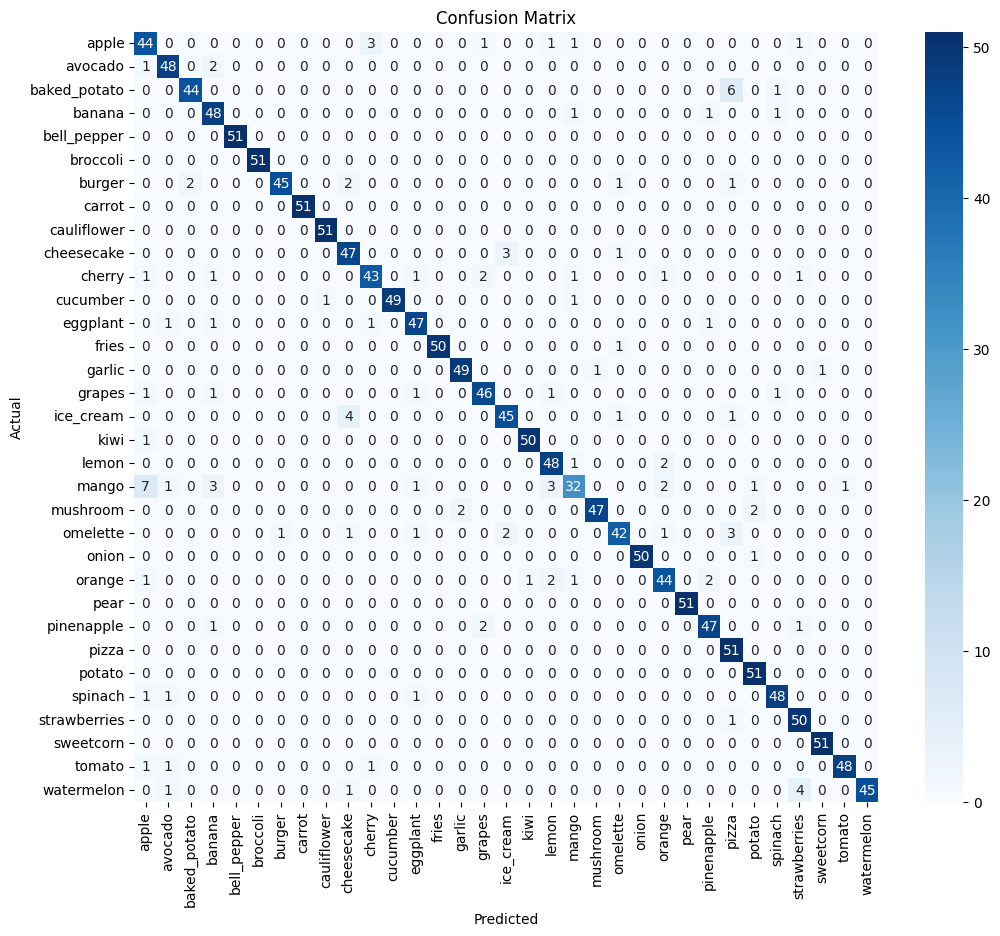

In [ ]:
# Matricea de confuzie
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# Salvare model
model.save("fruitveg_model.h5")

# Conversie la TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("fruitveg_model.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpcfvnqjqb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_314')
Output Type:
  TensorSpec(shape=(None, 33), dtype=tf.float32, name=None)
Captures:
  136893507817872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136893507819600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136893507819984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136893507819792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136893507818448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136893507821136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136893507821520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136893507821904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136893507821712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136893507819024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136893507

In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))


              precision    recall  f1-score   support

       apple       0.92      0.90      0.91        51
     avocado       0.92      0.96      0.94        51
      banana       0.98      0.92      0.95        51
 bell_pepper       1.00      1.00      1.00        51
    broccoli       1.00      1.00      1.00        51
      carrot       1.00      1.00      1.00        51
 cauliflower       1.00      1.00      1.00        51
      cherry       0.91      0.98      0.94        51
    cucumber       0.96      1.00      0.98        51
    eggplant       0.98      0.84      0.91        51
      garlic       0.96      0.96      0.96        51
      grapes       0.94      0.86      0.90        51
        kiwi       0.96      0.84      0.90        51
       lemon       0.91      0.96      0.93        51
       mango       0.79      0.80      0.80        51
    mushroom       0.94      0.96      0.95        51
       onion       0.83      0.98      0.90        51
      orange       0.87    

In [ ]:
# Resetăm generatorul pentru siguranță
test_gen.reset()

# Numărul de imagini
num_images = len(test_gen.filenames)

# Inițializare arrays pentru imagini și etichete
X = []
y_true = []

# Iterăm prin tot setul de test
for i in range(len(test_gen)):
    imgs, labels = test_gen[i]
    for img, label in zip(imgs, labels):
        X.append(img)
        y_true.append(np.argmax(label))

X = np.array(X)
y_true = np.array(y_true)

# Predictii
pred_probs = model.predict(X, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning:

Palette images with Transparency expressed in bytes should be converted to RGBA images



53/53 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step


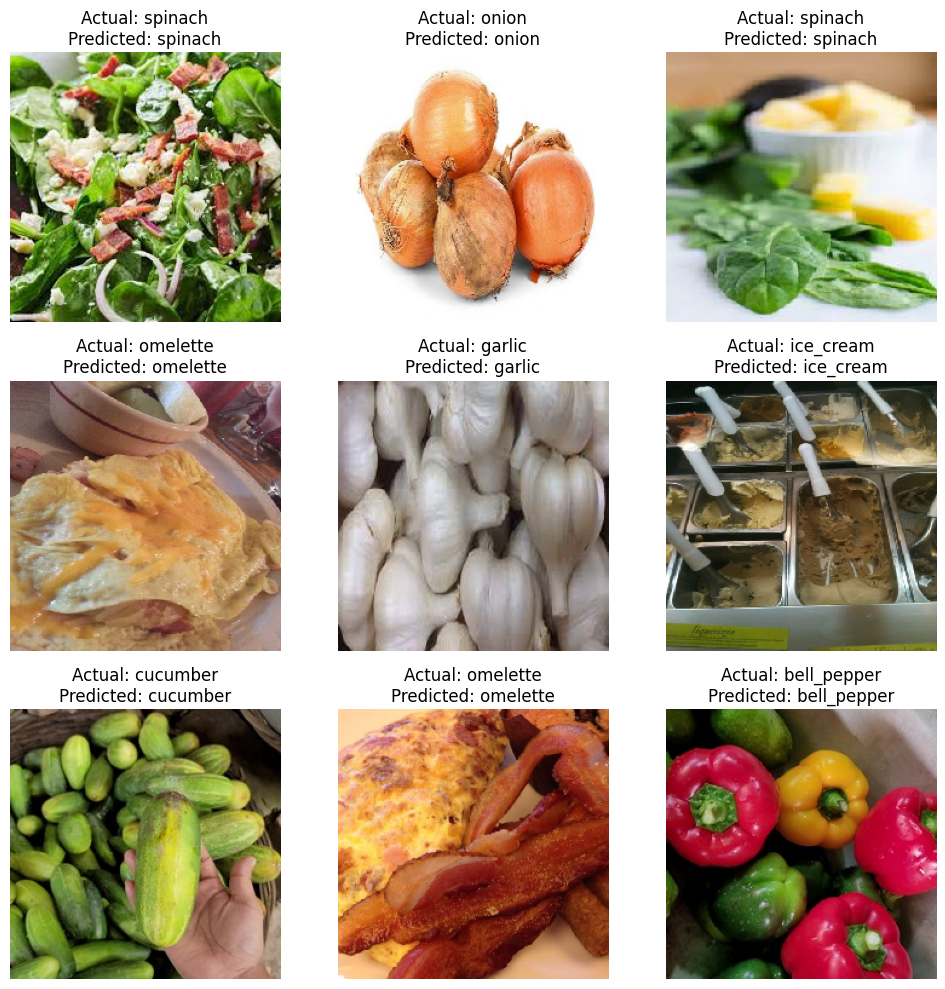

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

correct_idx = np.where(y_pred == y_true)[0]
num_to_display = 9

if len(correct_idx) >= num_to_display:
    selected_idx = np.random.choice(correct_idx, size=num_to_display, replace=False)
else:
    selected_idx = correct_idx

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    if i < len(selected_idx):
        idx = selected_idx[i]
        ax.imshow(X[idx])
        actual_label = class_names[y_true[idx]]
        predicted_label = class_names[y_pred[idx]]
        ax.set_title(f"Actual: {actual_label}\nPredicted: {predicted_label}")
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()
